# Imports

In [2]:
import regex as re
import json
import pandas as pd
from collections import defaultdict, Counter
from typing import List, Dict, Tuple, Set
import matplotlib.pyplot as plt

from tqdm import tqdm
import os

# Tokenizer

In [3]:
class BPETokenizer:    
    def __init__(self):
        gpt2_pattern = ( # source: https://github.com/openai/tiktoken/blob/97e49cbadd500b5cc9dbb51a486f0b42e6701bee/tiktoken/_educational.py#L209
            r"""'s|'t|'re|'ve|'m|'ll|'d| ?[\p{L}]+| ?[\p{N}]+| ?[^\s\p{L}\p{N}]+|\s+(?!\S)|\s+"""
        )
        self.pretokenize_pattern = re.compile(gpt2_pattern, re.UNICODE)
        
        self.vocab = {}
        self.id_to_token = {}
        self.merges = {}
        self.merge_ranks = {}
        self.special_tokens = {}
        
    def add_special_tokens(self, tokens):
        for token in tokens:
            if token not in self.special_tokens:
                self.special_tokens[token] = len(self.vocab) + len(self.special_tokens)
    
    def pretokenize(self, text):
        return self.pretokenize_pattern.findall(text)
    
    def merge(self, pair, words):
        new_words = {}
        replacement = pair[0] + pair[1]
        
        for word, freq in words.items():
            new_word = []
            i = 0
            while i < len(word):
                if i < len(word) - 1 and word[i] == pair[0] and word[i+1] == pair[1]:
                    new_word.append(replacement)
                    i += 2
                else:
                    new_word.append(word[i])
                    i += 1
            new_words[tuple(new_word)] = freq
        return new_words
    
    def train(self, texts, vocab_size: int = 1000):
        pretokenized = []
        for text in texts:
            pretokenized.extend(self.pretokenize(text))
        
        word_freqs = Counter(pretokenized)
        words = {
            tuple(bytes([b]) for b in word.encode('utf-8')): freq 
            for word, freq in word_freqs.items()
        }
        self.vocab = {bytes([i]): i for i in range(256)}
        offset = len(self.vocab)
        
        for token, token_id in self.special_tokens.items():
            self.vocab[token.encode('utf-8')] = token_id
        
        num_merges = vocab_size - len(self.vocab)
        pbar = tqdm(range(num_merges), desc="Training BPE")
        for rank in pbar:
            pairs = defaultdict(int)
            for word, freq in words.items():
                for i in range(len(word) - 1):
                    pairs[(word[i], word[i + 1])] += freq
    
            if not pairs:
                break
            
            best_pair = max(pairs, key=pairs.get)
            merged = best_pair[0] + best_pair[1]

            self.merges[best_pair] = merged
            self.merge_ranks[best_pair] = rank

            if merged not in self.vocab:
                self.vocab[merged] = len(self.vocab)

            new_words = {}
            for word, freq in words.items():
                new_word = []
                i = 0
                while i < len(word):
                    if i < len(word) - 1 and (word[i], word[i + 1]) == best_pair:
                        new_word.append(merged)
                        i += 2
                    else:
                        new_word.append(word[i])
                        i += 1
                new_words[tuple(new_word)] = freq

            words = new_words

        self.id_to_token = {v: k for k, v in self.vocab.items()}
        print(f"Training finished. Vocab size: {len(self.vocab)}")
    
    def encode_word(self, word):
        tokens = [bytes([b]) for b in word.encode("utf-8")]

        while True:
            pairs = [(tokens[i], tokens[i + 1]) for i in range(len(tokens) - 1)]

            best_rank = float("inf")
            best_idx = None
            best_pair = None

            for i, pair in enumerate(pairs):
                rank = self.merge_ranks.get(pair)
                if rank is not None and rank < best_rank:
                    best_rank = rank
                    best_pair = pair
                    best_idx = i

            if best_pair is None:
                break

            tokens = (
                tokens[:best_idx]
                + [self.merges[best_pair]]
                + tokens[best_idx + 2 :]
            )

        return [self.vocab[tok] for tok in tokens]
    
    def encode(self, text):
        words = self.pretokenize(text)
        ids = []
        for word in words:
            ids.extend(self.encode_word(word))
        return ids
    
    def decode(self, ids):
        return b"".join(self.id_to_token[i] for i in ids).decode(
            "utf-8", errors="ignore"
        )

# Task 1

In [106]:
df_jokes = pd.read_csv('/kaggle/input/russian-jokes/jokes.csv')
df_medical = pd.read_csv('/kaggle/input/medsi-articles/Articles.csv')
df_review = pd.read_csv('/kaggle/input/t1-sentiment-classification-russian-reviews/test.csv')

In [5]:
def get_train_size(df):
    total = len(df)
    ratio = 0.9
    return min(150, int(ratio * total))


training_corpus_jokes = df_jokes['text'].dropna().head(get_train_size(df_jokes)).tolist()
training_corpus_medical = df_medical['text'].dropna().head(get_train_size(df_medical)).tolist()
training_corpus_review = df_review['review'].dropna().head(get_train_size(df_review)).tolist()

training_corpus = training_corpus_jokes + training_corpus_medical + training_corpus_review
print(f"Размер train корпуса: {len(training_corpus)}")

Размер train корпуса: 450


In [6]:
def get_test_size(df):
    total = len(df)
    ratio = 0.1
    return min(10, int(ratio * total))


test_corpus_jokes = df_jokes['text'].dropna().iloc[get_train_size(df_jokes):get_train_size(df_jokes) + get_test_size(df_jokes)].tolist()
test_corpus_medical = df_medical['text'].dropna().iloc[get_train_size(df_medical):get_train_size(df_medical) + get_test_size(df_medical)].tolist()
test_corpus_review = df_review['review'].dropna().iloc[get_train_size(df_review):get_train_size(df_review) + get_test_size(df_review)].tolist()

test_corpus = test_corpus_jokes + test_corpus_medical + test_corpus_review
print(f"Размер test корпуса: {len(test_corpus)}")

Размер test корпуса: 30


In [7]:
tokenizer = BPETokenizer()
tokenizer.add_special_tokens(['<BOS>', '<EOS>', '<PAD>', '<UNK>'])

In [8]:
tokenizer.train(training_corpus, vocab_size=5000)

Training BPE: 100%|██████████| 4740/4740 [05:01<00:00, 15.71it/s]

Training finished. Vocab size: 5000


In [8]:
text = test_corpus[0]
tokens = tokenizer.encode(text)
decoded = tokenizer.decode(tokens)
print(f"Оригинал: '{text}'")
print(f"Токенов: {len(tokens)}")
print(f"токены: {tokens}")
print(f"Декодировано: {decoded}")

Оригинал: 'Программиста из Микрософта послали на военные сборы. Стреляет он на стрельбище из автомата - все пули мимо. Ему кричат со стороны мишени:
- Эй посмотри на свой автомат у тебя какая-то проблема с ним.
Он смотрит на автомат потом подносит палец к дулу и нажимает на спусковой крючок. Палец отлетает. Он кричит в ответ:
- С моей стороны все нормально пули вылетают. Проблема где-то на вашей стороне.

'
Токенов: 168
токены: [410, 268, 938, 395, 281, 263, 463, 550, 580, 1928, 396, 1913, 532, 270, 406, 354, 1052, 1173, 292, 1562, 275, 46, 1953, 297, 3645, 545, 354, 416, 297, 305, 1094, 1279, 463, 2083, 462, 299, 263, 920, 776, 283, 2088, 316, 339, 260, 46, 604, 805, 1375, 643, 1127, 4286, 1378, 328, 280, 262, 58, 13, 10, 45, 465, 262, 783, 532, 2041, 354, 3304, 783, 2083, 462, 299, 360, 641, 1835, 520, 467, 45, 366, 4167, 292, 298, 339, 46, 13, 10, 4945, 292, 2041, 265, 354, 2083, 462, 299, 1331, 307, 526, 300, 269, 320, 283, 1727, 295, 310, 327, 1132, 273, 288, 298, 401, 339, 3

In [10]:
def calculate_metrics(tokenizer, texts):
    total_tokens = 0
    total_bytes = 0
    all_words = []
    
    for text in texts:
        tokens = tokenizer.encode(text)
        total_tokens += len(tokens)
        total_bytes += len(text.encode('utf-8'))
        all_words.extend(text.split())

    compression_ratio = total_tokens / total_bytes
    avg_tokens_per_word = total_tokens / len(all_words)
    word_counts = Counter(all_words)
    top_10_threshold = max(1, int(len(word_counts) * 0.1))
    top_words = [word for word, count in word_counts.most_common(top_10_threshold)]
    
    top_tokens_total = sum(len(tokenizer.encode(w)) for w in top_words)
    avg_tokens_top_10 = top_tokens_total / len(top_words)
    
    return {
        "compression_ratio": compression_ratio,
        "avg_tokens_per_word": avg_tokens_per_word,
        "avg_tokens_top_10": avg_tokens_top_10
    }

calculate_metrics(tokenizer, test_corpus)

{'compression_ratio': 0.14284255614607425,
 'avg_tokens_per_word': 2.3007154016939397,
 'avg_tokens_top_10': 2.4556962025316458}

In [18]:
metrics_jokes = calculate_metrics(tokenizer, test_corpus_jokes)
metrics_medical = calculate_metrics(tokenizer, test_corpus_medical)
metrics_review = calculate_metrics(tokenizer, test_corpus_review)

import pandas as pd

comparison_df = pd.DataFrame({
    "Анекдоты": metrics_jokes,
    "Медицина": metrics_medical,
    "Рецензии": metrics_review
}).T

print(comparison_df)

          compression_ratio  avg_tokens_per_word  avg_tokens_top_10
Анекдоты           0.242429             2.920145           2.050000
Медицина           0.139009             2.353126           2.278689
Рецензии           0.141345             1.892285           2.223214


Действительно, для разных доменов метрики отличаются. Для медицины наблюдается лучшая эффективность, а для анекдотов худшая. Видимо, в анекдотах часто встречаются разговорные обороты и специфические слова (например, маты...), в то время как в медицинских текстах и рецензиях чаще встречаются слова более общего употребления

In [12]:
ratios = []
actual_vocabs = []
vocabs = [300, 600, 1000, 1500, 2000]
for v_size in vocabs:
    temp_tkn = BPETokenizer()
    temp_tkn.add_special_tokens(['<BOS>', '<EOS>', '<PAD>', '<UNK>'])
    temp_tkn.train(training_corpus, vocab_size=v_size)
    
    m = calculate_metrics(temp_tkn, test_corpus)
    ratios.append(m['compression_ratio'])
    actual_vocabs.append(len(temp_tkn.vocab))

Training BPE: 100%|██████████| 40/40 [00:07<00:00,  5.32it/s]


Training finished. Vocab size: 300


Training BPE: 100%|██████████| 340/340 [00:41<00:00,  8.26it/s]


Training finished. Vocab size: 600


Training BPE: 100%|██████████| 740/740 [01:18<00:00,  9.47it/s]


Training finished. Vocab size: 1000


Training BPE: 100%|██████████| 1240/1240 [02:01<00:00, 10.20it/s]


Training finished. Vocab size: 1500


Training BPE: 100%|██████████| 1740/1740 [02:45<00:00, 10.49it/s]


Training finished. Vocab size: 2000


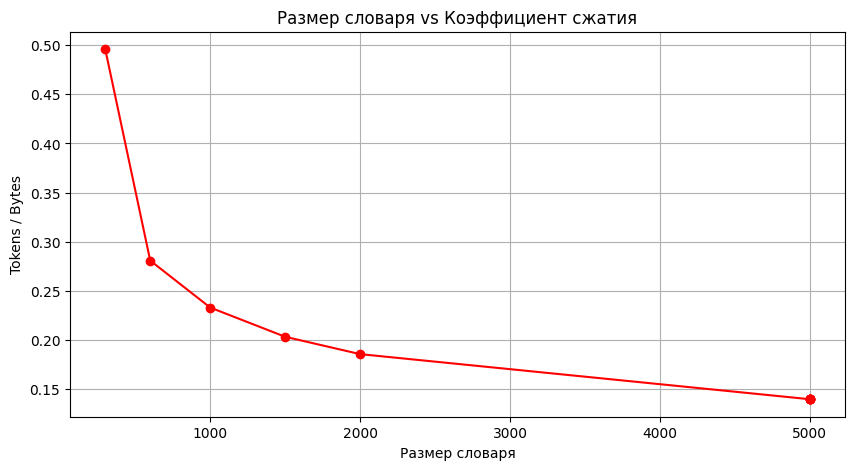

In [17]:
actual_vocabs.append(5000)
ratios.append("0.14")

plt.figure(figsize=(10, 5))
plt.plot(actual_vocabs, list(map(float, ratios)), marker='o', linestyle='-', color='red')
plt.title("Размер словаря vs Коэффициент сжатия")
plt.xlabel("Размер словаря")
plt.ylabel("Tokens / Bytes")
plt.grid(True)
plt.show()

In [22]:
used_tokens = set()
folder_path = "/kaggle/input/pushkin-texts"
files = [f for f in os.listdir(folder_path) if f.endswith('.txt')]
    
for filename in files:
    file_path = os.path.join(folder_path, filename)
    with open(file_path, 'r', encoding='utf-8', errors='ignore') as f:
        text = f.read()
        encoded_ids = tokenizer.encode(text)
        used_tokens.update(encoded_ids)

all_token_ids = set(tokenizer.vocab.values())

unused_tokens = all_token_ids - used_tokens

total_count = len(all_token_ids)
unused_count = len(unused_tokens)
usage_percentage = (len(used_tokens.intersection(all_token_ids)) / total_count) * 100
unused_percentage = (unused_count / total_count) * 100

print(f"Токенов НЕ использовано: {unused_count}")
print(f"Доля неиспользованных токенов: {unused_percentage:.2f}%")

Токенов НЕ использовано: 2384
Доля неиспользованных токенов: 47.72%


# Task 1.1

In [9]:
import torch
import torch.nn as nn
from torch.utils.data import Dataset, DataLoader

from sklearn.model_selection import train_test_split
from IPython.display import clear_output

In [10]:
class TextDataset(Dataset):
    def __init__(self, texts, labels, tokenizer, max_len=64):
        self.tokenizer = tokenizer
        self.max_len = max_len
        self.data = []
        self.labels = labels
        
        pad_id = tokenizer.special_tokens.get('<PAD>', 0)
        
        for text in texts:
            tokens = tokenizer.encode(text)
            if len(tokens) < max_len:
                tokens += [pad_id] * (max_len - len(tokens))
            else:
                tokens = tokens[:max_len]
            self.data.append(torch.tensor(tokens))

    def __len__(self):
        return len(self.data)

    def __getitem__(self, idx):
        return self.data[idx], torch.tensor(self.labels[idx])

In [11]:
class SimpleRNN(nn.Module):
    def __init__(self, vocab_size, embed_dim, hidden_dim, output_dim):
        super().__init__()
        self.embedding = nn.Embedding(vocab_size, embed_dim)
        self.lstm = nn.LSTM(embed_dim, hidden_dim, batch_first=True)
        self.fc = nn.Linear(hidden_dim, output_dim)
        
    def forward(self, text):
        embedded = self.embedding(text)
        output, (hidden, cell) = self.lstm(embedded)
        return self.fc(hidden[-1])

In [25]:
# Так как не указано, на какую именно задачу обучать, обучим на бинарную классификацию домена текста
texts = test_corpus_jokes + test_corpus_medical
labels = [0] * len(test_corpus_jokes) + [1] * len(test_corpus_medical)

train_texts, val_texts, train_labels, val_labels = train_test_split(
    texts, labels, test_size=0.2, random_state=42, stratify=labels
)

train_dataset = TextDataset(train_texts, train_labels, tokenizer)
val_dataset = TextDataset(val_texts, val_labels, tokenizer)

train_loader = DataLoader(train_dataset, batch_size=16, shuffle=True)
val_loader = DataLoader(val_dataset, batch_size=16, shuffle=False)

In [29]:
def plot_progress(train_losses, val_losses, val_accs):
    clear_output(wait=True)
    fig, ax = plt.subplots(1, 2, figsize=(15, 5))
    
    ax[0].plot(train_losses, label='Train Loss')
    ax[0].plot(val_losses, label='Val Loss')
    ax[0].set_title('Model Loss')
    ax[0].set_xlabel('Epoch')
    ax[0].set_ylabel('Loss')
    ax[0].legend()
    ax[0].grid(True)
    
    ax[1].plot(val_accs, label='Val Accuracy', color='green')
    ax[1].set_title('Validation Accuracy')
    ax[1].set_xlabel('Epoch')
    ax[1].set_ylabel('Accuracy')
    ax[1].legend()
    ax[1].grid(True)
    
    plt.show()

In [30]:
model = SimpleRNN(vocab_size=len(tokenizer.vocab), embed_dim=128, hidden_dim=256, output_dim=2)
optimizer = torch.optim.Adam(model.parameters(), lr=0.001)
criterion = nn.CrossEntropyLoss()

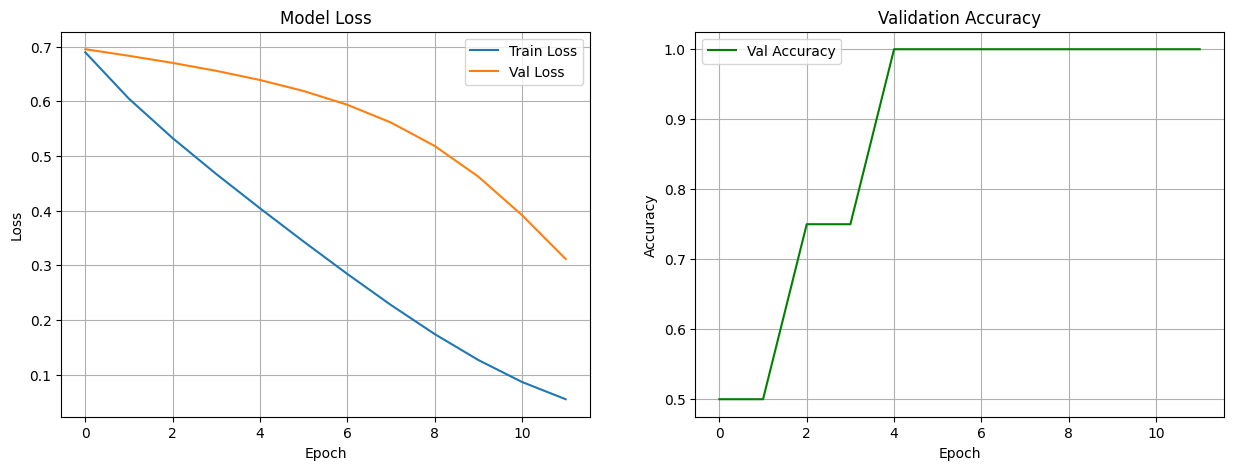

In [31]:
train_losses, val_losses, val_accs = [], [], []

for epoch in range(12):
    model.train()
    curr_train_loss = 0
    for batch_text, batch_labels in train_loader:
        optimizer.zero_grad()
        preds = model(batch_text)
        loss = criterion(preds, batch_labels)
        loss.backward()
        optimizer.step()
        curr_train_loss += loss.item()
    
    model.eval()
    curr_val_loss = 0
    correct = 0
    total = 0
    with torch.no_grad():
        for batch_text, batch_labels in val_loader:
            preds = model(batch_text)
            loss = criterion(preds, batch_labels)
            curr_val_loss += loss.item()
            
            probs = torch.argmax(preds, dim=1)
            correct += (probs == batch_labels).sum().item()
            total += batch_labels.size(0)
    
    train_losses.append(curr_train_loss / len(train_loader))
    val_losses.append(curr_val_loss / len(val_loader))
    val_accs.append(correct / total)
    
    plot_progress(train_losses, val_losses, val_accs)

# Task 1.2

In [110]:
import torch
import torch.nn as nn
from torch.utils.data import Dataset, DataLoader
from transformers import GPT2LMHeadModel, GPT2Config, get_linear_schedule_with_warmup
from peft import LoraConfig, get_peft_model
from tqdm import tqdm
import matplotlib.pyplot as plt
from IPython.display import clear_output

import numpy as np

In [111]:
class GPTRussianDataset(Dataset):
    def __init__(self, texts, tokenizer, max_len=128):
        self.tokenizer = tokenizer
        self.input_ids = []
        pad_id = tokenizer.vocab.get(b'<PAD>', 0)
        
        for text in texts:
            encoded = tokenizer.encode(text)
            if len(encoded) < max_len:
                encoded += [pad_id] * (max_len - len(encoded))
            else:
                encoded = encoded[:max_len]
            
            self.input_ids.append(torch.tensor(encoded))

    def __len__(self):
        return len(self.input_ids)

    def __getitem__(self, idx):
        return self.input_ids[idx], self.input_ids[idx]

In [112]:
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
model_name = "gpt2"
model = GPT2LMHeadModel.from_pretrained(model_name)
config = model.config
new_vocab_size = len(tokenizer.vocab)

model.resize_token_embeddings(new_vocab_size)

Embedding(5000, 768)

In [113]:
lora_config = LoraConfig(
    r=16, 
    lora_alpha=32, 
    target_modules=["c_attn"],
    lora_dropout=0.05,
    bias="none", 
    task_type="CAUSAL_LM"
)
model = get_peft_model(model, lora_config)
model.to(device)

/usr/local/lib/python3.12/dist-packages/peft/tuners/lora/layer.py:2174: UserWarning: fan_in_fan_out is set to False but the target module is `Conv1D`. Setting fan_in_fan_out to True.
  warnings.warn(


PeftModelForCausalLM(
  (base_model): LoraModel(
    (model): GPT2LMHeadModel(
      (transformer): GPT2Model(
        (wte): Embedding(5000, 768)
        (wpe): Embedding(1024, 768)
        (drop): Dropout(p=0.1, inplace=False)
        (h): ModuleList(
          (0-11): 12 x GPT2Block(
            (ln_1): LayerNorm((768,), eps=1e-05, elementwise_affine=True)
            (attn): GPT2Attention(
              (c_attn): lora.Linear(
                (base_layer): Conv1D(nf=2304, nx=768)
                (lora_dropout): ModuleDict(
                  (default): Dropout(p=0.05, inplace=False)
                )
                (lora_A): ModuleDict(
                  (default): Linear(in_features=768, out_features=16, bias=False)
                )
                (lora_B): ModuleDict(
                  (default): Linear(in_features=16, out_features=2304, bias=False)
                )
                (lora_embedding_A): ParameterDict()
                (lora_embedding_B): ParameterDict()
         

In [114]:
def train_epoch(model, loader, optimizer, scheduler):
    model.train()

    total_loss = 0
    for inputs, labels in tqdm(loader, desc="Training"):
        inputs, labels = inputs.to(device), labels.to(device)
        
        optimizer.zero_grad()
        outputs = model(input_ids=inputs, labels=labels)
        loss = outputs.loss
        loss.backward()
        optimizer.step()
        scheduler.step()
        total_loss += loss.item()
    
    return total_loss / len(loader)

In [115]:
train_texts, val_texts = train_test_split(training_corpus, test_size=0.15, random_state=42)

train_ds = GPTRussianDataset(train_texts, tokenizer)
val_ds = GPTRussianDataset(val_texts, tokenizer)

train_loader = DataLoader(train_ds, batch_size=8, shuffle=True)
val_loader = DataLoader(val_ds, batch_size=8, shuffle=False)

train_losses, val_losses, perplexities = [], [], []

In [116]:
optimizer = torch.optim.AdamW(model.parameters(), lr=1e-4)
num_epochs = 40
scheduler = get_linear_schedule_with_warmup(optimizer, num_warmup_steps=100, num_training_steps=len(train_loader) * num_epochs)

In [117]:
def validate(model, loader, device):
    model.eval()
    total_loss = 0
    
    with torch.no_grad():
        for inputs, labels in loader:
            inputs, labels = inputs.to(device), labels.to(device)
            outputs = model(input_ids=inputs, labels=labels)
            total_loss += outputs.loss.item()
            
    avg_loss = total_loss / len(loader)
    perplexity = np.exp(avg_loss)
    
    return avg_loss, perplexity

In [93]:
def generate_text(model, tokenizer, prompt, max_length=50):
    model.eval()
    input_ids = torch.tensor([tokenizer.encode(prompt)]).to(device)
    
    output_ids = model.generate(
        input_ids, 
        max_length=max_length, 
        num_return_sequences=1,
        pad_token_id=tokenizer.vocab.get(b'<PAD>', 0),
        no_repeat_ngram_size=2,
        do_sample=True,
        top_k=50,
        top_p=0.95
    )
    
    generated_tokens = output_ids[0].tolist()
    return tokenizer.decode(generated_tokens)

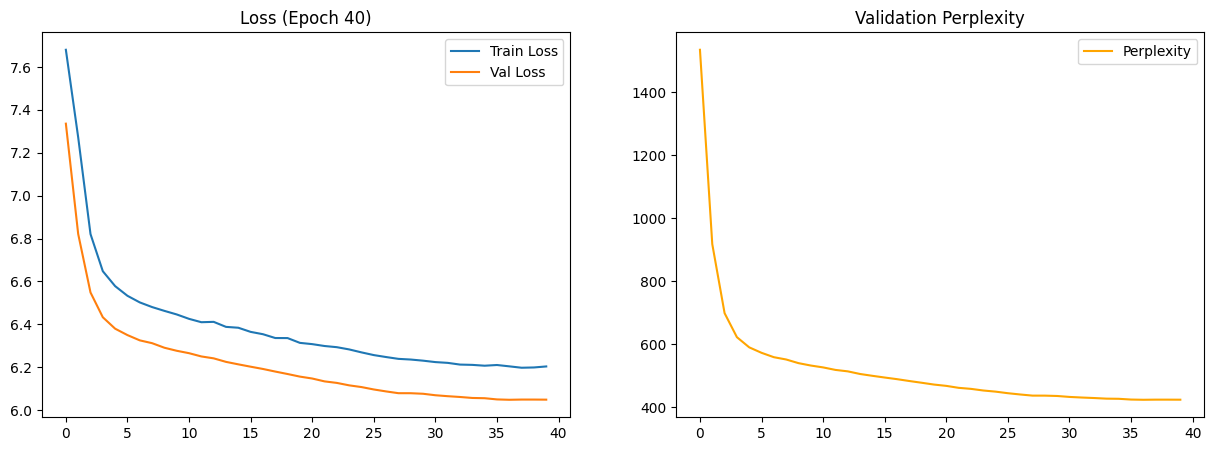

In [118]:
for epoch in range(num_epochs):
    train_loss = train_epoch(model, train_loader, optimizer, scheduler)
    
    val_loss, val_ppl = validate(model, val_loader, device)
    
    train_losses.append(train_loss)
    val_losses.append(val_loss)
    perplexities.append(val_ppl)
    
    clear_output(wait=True)
    fig, ax = plt.subplots(1, 2, figsize=(15, 5))
    
    ax[0].plot(train_losses, label='Train Loss')
    ax[0].plot(val_losses, label='Val Loss')
    ax[0].set_title(f"Loss (Epoch {epoch+1})")
    ax[0].legend()
    
    ax[1].plot(perplexities, label='Perplexity', color='orange')
    ax[1].set_title("Validation Perplexity")
    ax[1].legend()
    
    plt.show()

# Task 2

In [150]:
from transformers import AutoModelForCausalLM, AutoTokenizer, TrainingArguments, Trainer
import random

In [151]:
def clean_joke(text):
    if not isinstance(text, str): return ""
    text = text.replace('\n', ' ').replace('\r', ' ')
    text = re.sub(r'\s+', ' ', text).strip()
    return text

In [152]:
training_corpus_jokes = df_jokes['text'].dropna().tolist()
cleaned_jokes = [clean_joke(joke) for joke in training_corpus_jokes if len(joke) > 10]

In [153]:
class JokesDataset(Dataset):
    def __init__(self, texts, tokenizer, max_len=128):
        self.tokenizer = tokenizer
        self.encodings = tokenizer(
            texts, 
            truncation=True, 
            max_length=max_len, 
            padding="max_length",
            return_tensors="pt"
        )

    def __len__(self):
        return len(self.encodings['input_ids'])

    def __getitem__(self, idx):
        item = {key: val[idx] for key, val in self.encodings.items()}
        item['labels'] = item['input_ids'].clone()
        return item

In [154]:
model_name = "Qwen/Qwen3-0.6B"
tokenizer = AutoTokenizer.from_pretrained(model_name)
tokenizer.pad_token = tokenizer.eos_token

model = AutoModelForCausalLM.from_pretrained(
    model_name,
    torch_dtype=torch.bfloat16 if torch.cuda.is_bf16_supported() else torch.float16,
    device_map="auto"
).to(device)

In [155]:
device

device(type='cuda')

In [156]:
lora_config = LoraConfig(
    r=32,
    lora_alpha=64,
    target_modules=["q_proj", "k_proj", "v_proj", "o_proj", "gate_proj", "up_proj", "down_proj"],
    lora_dropout=0.05,
    task_type="CAUSAL_LM"
)
model = get_peft_model(model, lora_config)
model.print_trainable_parameters()

trainable params: 20,185,088 || all params: 616,235,008 || trainable%: 3.2756


In [157]:
sampled_jokes = random.sample(cleaned_jokes, 13_000)

In [158]:
dataset = JokesDataset(sampled_jokes, tokenizer)

training_args = TrainingArguments(
    output_dir="/kaggle/working/qwen_jokes_results",
    per_device_train_batch_size=4,
    gradient_accumulation_steps=4,
    learning_rate=2e-4,
    num_train_epochs=2,
    lr_scheduler_type="cosine",
    warmup_ratio=0.1,
    fp16=not torch.cuda.is_bf16_supported(),
    bf16=torch.cuda.is_bf16_supported(),
    logging_steps=5,
    save_strategy="no",
    report_to="none"
)

trainer = Trainer(
    model=model,
    args=training_args,
    train_dataset=dataset,
)

trainer.train()

The model is already on multiple devices. Skipping the move to device specified in `args`.


Step,Training Loss
5,9.342300
10,8.213700
15,6.985800
20,4.873400
25,2.559300
30,1.866000
35,1.780400
40,1.584000
45,1.557400
50,1.609700


TrainOutput(global_step=814, training_loss=1.4973412971824627, metrics={'train_runtime': 3611.1523, 'train_samples_per_second': 7.2, 'train_steps_per_second': 0.225, 'total_flos': 9198309998592000.0, 'train_loss': 1.4973412971824627, 'epoch': 2.0})

In [168]:
with open('/kaggle/input/prefixes/prefixes.txt', 'r', encoding='utf-8') as f:
    content = f.read()

pattern = r'^\d+\.?\s+(.*)$'
prefixes = re.findall(pattern, content, re.MULTILINE)

prefixes = [p.strip() for p in prefixes if p.strip()]

print(f"префиксов: {len(prefixes)}")

префиксов: 75


In [169]:
output_file = "/kaggle/working/generated_jokes_good.txt"

model.eval()

with open(output_file, 'w', encoding='utf-8') as f_out:
    for prefix in tqdm(prefixes):
        prompt = f"{prefix}" 
        
        inputs = tokenizer(prompt, return_tensors="pt").to(model.device)
        
        with torch.no_grad():
            outputs = model.generate(
                **inputs,
                max_new_tokens=100,
                do_sample=True,
                temperature=0.8,
                top_p=0.9,
                repetition_penalty=1.1,
                eos_token_id=tokenizer.eos_token_id,
                pad_token_id=tokenizer.pad_token_id
            )
        
        full_text = tokenizer.decode(outputs[0], skip_special_tokens=True)
        clean_joke = full_text.replace('\n', ' ').replace('\r', ' ').strip()
        print(clean_joke)
        f_out.write(clean_joke + '\n')

  1%|▏         | 1/75 [00:03<04:44,  3.84s/it]

Идёт мужик по лесу. Впереди ехнет лёд, подходит к нему девушка и спрашивает: -Дорогой, а почему ты в таком месте? -Это мой табуреток!


  3%|▎         | 2/75 [00:07<04:14,  3.48s/it]

Встречаются два друга. Один говорит второму: - Дорогой, ты что вчера с ней случал? Второй ему отвечает: - Ничего не случилось...


  4%|▍         | 3/75 [00:11<04:49,  4.02s/it]

...

Я из тех людей, которые могут мне доверить, у меня всегда одна пара.


 99%|█████████▊| 74/75 [04:06<00:01,  1.79s/it]

- Я нормальный. - Как? - Нормальное, значит я счастливый!


100%|██████████| 75/75 [04:09<00:00,  3.32s/it]

Есть только одна система: 1950 год, Маркс. 2060 год, Эрнст Генерал-майор Кама.
